# Analiza euroejskich lig

Zbiór danych: *European Top Leagues Player Stats 25-26* (Kaggle).  


**Spis treści:**
1. Wczytanie i przygotowanie danych
2. EDA
3. Inżynieria cech i preprocessing
4. Klasteryzacja zawodników (KMeans + PCA)
5. Regresja — przewidywanie wartości rynkowej
6. Klasyfikacja pozycji zawodnika
7. Weryfikacja hipotez statystycznych


## Importy

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, roc_auc_score, silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(42)

---
## 1. Wczytanie danych

In [2]:
DATA_DIR = Path("data/13")

profiles_df = pd.read_csv(DATA_DIR / "all_player_profiles.csv")
stats_df = pd.read_csv(DATA_DIR / "all_player_stats.csv")

df = profiles_df.merge(stats_df, on=["player_id", "league"], how="inner")
print(f"Profiles: {len(profiles_df)}, Stats: {len(stats_df)}, Merged: {len(df)}")
df.head()

Profiles: 4740, Stats: 3749, Merged: 3749


,player_id,name,league,position,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
0,804508,Viktor Gyökeres,Premier League,F,61000000.0,30,24,1997,12,0,10.3733,1.773005,6.573333,47,18,5,0,6,1,0
1,934235,Bukayo Saka,Premier League,F,126000000.0,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0
2,794839,Gabriel Jesus,Premier League,F,21000000.0,12,2,320,2,0,1.8434,0.247789,6.541667,15,10,2,0,4,2,0
3,922573,Gabriel Martinelli,Premier League,F,42000000.0,26,10,906,1,3,3.3793,0.999809,6.607692,25,10,2,0,10,0,0
4,836705,Kai Havertz,Premier League,F,48000000.0,7,4,318,0,1,1.2721,0.105223,6.557143,7,1,0,0,5,0,0


---
## 2. EDA

In [3]:
df.info()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 3749 entries, 0 to 3748
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3749 non-null   int64  
 1   name              3749 non-null   str    
 2   league            3749 non-null   str    
 3   position          3749 non-null   str    
 4   market_value      3682 non-null   float64
 5   appearances       3749 non-null   int64  
 6   matches_started   3749 non-null   int64  
 7   minutes_played    3749 non-null   int64  
 8   goals             3749 non-null   int64  
 9   assists           3749 non-null   int64  
 10  expected_goals    3182 non-null   float64
 11  expected_assists  3723 non-null   float64
 12  rating            3749 non-null   float64
 13  total_shots       3749 non-null   int64  
 14  shots_on_target   3749 non-null   int64  
 15  yellow_cards      3749 non-null   int64  
 16  red_cards         3749 non-null   int64  
 17  tackle

expected_goals      567
market_value         67
expected_assists     26
player_id             0
position              0
league                0
name                  0
appearances           0
minutes_played        0
matches_started       0
assists               0
goals                 0
rating                0
total_shots           0
shots_on_target       0
yellow_cards          0
red_cards             0
tackles               0
interceptions         0
saves                 0
dtype: int64

In [4]:
df.describe()

,player_id,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
count,3.749000e+03,3.682000e+03,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3182.000000,3.723000e+03,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000
mean,9.305713e+05,9.876458e+06,17.716458,12.775407,1149.305682,1.559883,1.097893,1.900095,1.139630e+00,6.712760,14.596959,5.029341,2.255001,0.116564,18.397173,9.673780,3.528674
std,4.638789e+05,1.653617e+07,8.989226,9.368521,795.092890,2.677618,1.690348,2.507885,1.407608e+00,0.662333,16.676500,6.831381,2.159107,0.347295,17.137989,10.314712,15.801667
min,7.910000e+02,2.300000e+04,1.000000,0.000000,1.000000,0.000000,0.000000,0.003200,9.300000e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.018370e+05,1.100000e+06,10.000000,4.000000,452.000000,0.000000,0.000000,0.373650,1.515899e-01,6.600000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000
50%,9.552450e+05,3.600000e+06,20.000000,12.000000,1072.000000,1.000000,0.000000,1.018200,6.547458e-01,6.742308,9.000000,3.000000,2.000000,0.000000,14.000000,6.000000,0.000000
75%,1.131541e+06,1.160000e+07,25.000000,21.000000,1821.000000,2.000000,2.000000,2.287525,1.579777e+00,6.905882,20.000000,7.000000,3.000000,0.000000,29.000000,15.000000,0.000000
max,2.492573e+06,2.180000e+08,32.000000,32.000000,2880.000000,31.000000,18.000000,24.383200,1.481861e+01,9.700000,122.000000,61.000000,12.000000,3.000000,97.000000,63.000000,145.000000


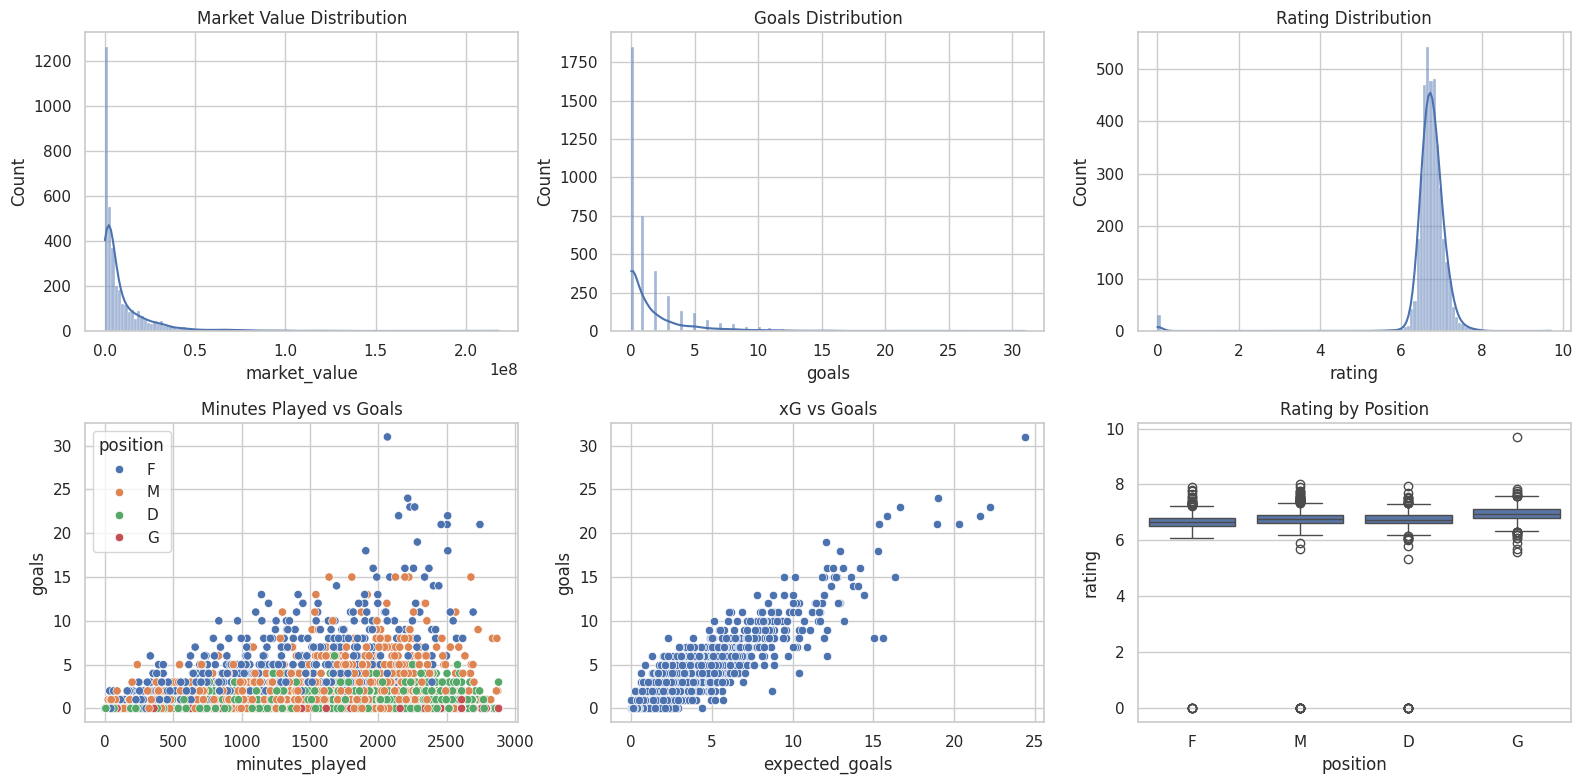

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.histplot(df["market_value"].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Market Value Distribution")

sns.histplot(df["goals"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Goals Distribution")

sns.histplot(df["rating"], kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Rating Distribution")

sns.scatterplot(data=df, x="minutes_played", y="goals", hue="position", ax=axes[1, 0])
axes[1, 0].set_title("Minutes Played vs Goals")

sns.scatterplot(data=df, x="expected_goals", y="goals", ax=axes[1, 1])
axes[1, 1].set_title("xG vs Goals")

sns.boxplot(data=df, x="position", y="rating", ax=axes[1, 2])
axes[1, 2].set_title("Rating by Position")

plt.tight_layout()
plt.show()

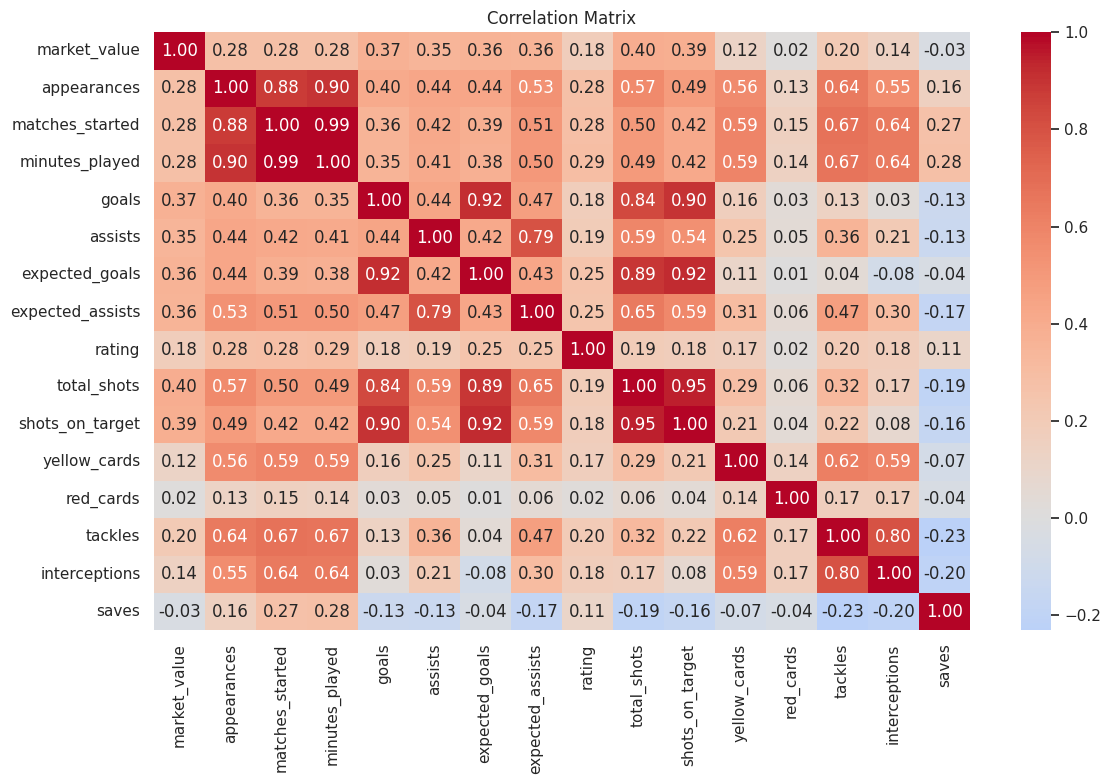

In [6]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include="number").columns.drop("player_id")
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

---
## 3. Preprocessing

In [7]:
df = df[df["minutes_played"] >= 600].reset_index(drop=True)
print(f"After minutes filter (>=600): {len(df)} players")

per90_stats = [
    "goals", "assists", "tackles", "interceptions", "saves",
    "total_shots", "shots_on_target", "expected_goals", "expected_assists",
]
for col in per90_stats:
    df[f"{col}_per90"] = df[col] * 90 / df["minutes_played"]

feature_columns = [
    "position", "league",
    "market_value", "appearances", "matches_started", "minutes_played",
    "goals_per90", "assists_per90", "expected_goals_per90", "expected_assists_per90",
    "rating", "total_shots_per90", "shots_on_target_per90",
    "yellow_cards", "tackles_per90", "interceptions_per90", "saves_per90",
]

X = df[feature_columns].copy()

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

X_prepared = preprocessor.fit_transform(X)
print(f"\nShape after preprocessing: {X_prepared.shape}")

After minutes filter (>=600): 2580 players
Numeric features (15): ['market_value', 'appearances', 'matches_started', 'minutes_played', 'goals_per90', 'assists_per90', 'expected_goals_per90', 'expected_assists_per90', 'rating', 'total_shots_per90', 'shots_on_target_per90', 'yellow_cards', 'tackles_per90', 'interceptions_per90', 'saves_per90']
Categorical features (2): ['position', 'league']

Shape after preprocessing: (2580, 27)


---
## 4. Klasteryzacja zawodników (KMeans + PCA)

### 4a. Dobór liczby klastrów

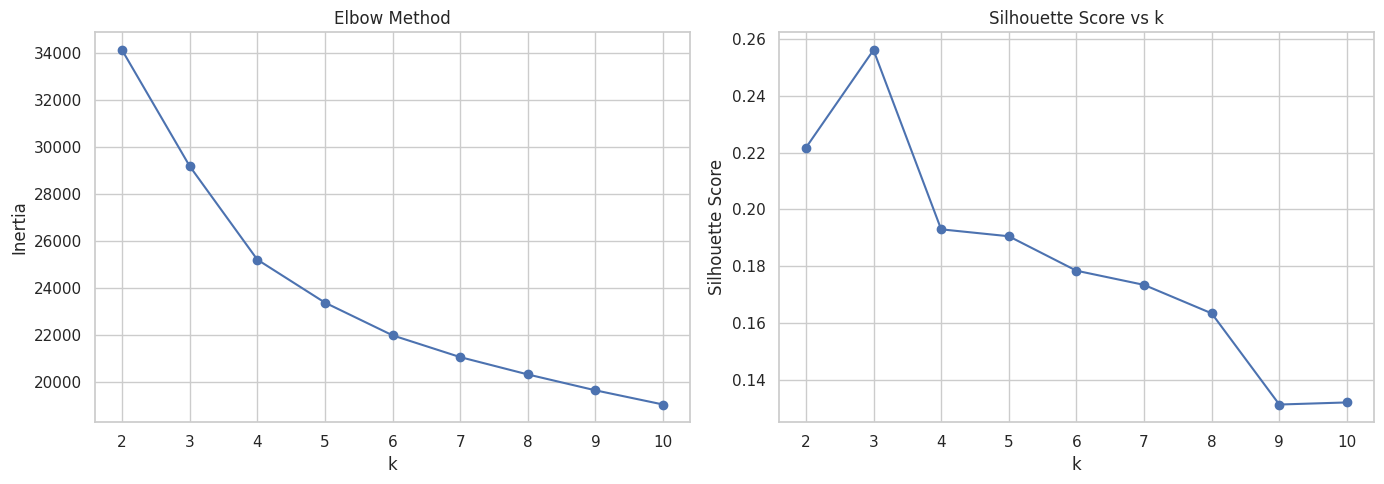

Best k by silhouette: 3 (score=0.2561)


In [8]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_prepared)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_prepared, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(K_range, silhouettes, "o-")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k} (score={max(silhouettes):.4f})")

### 4b. KMeans z wybraną liczbą klastrów

In [9]:
N_CLUSTERS = best_k

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_prepared)

analysis_df = df.copy()
analysis_df["cluster"] = clusters

print("Cluster sizes:")
print(analysis_df.groupby("cluster").size())
print(f"\nSilhouette score: {silhouette_score(X_prepared, clusters):.4f}")

Cluster sizes:
cluster
0    1642
1     742
2     196
dtype: int64

Silhouette score: 0.2561


In [10]:
# Cluster profiles — mean values of key features
cluster_profile = analysis_df.groupby("cluster")[
    ["market_value", "goals", "assists", "rating", "minutes_played",
     "tackles", "interceptions", "saves", "yellow_cards", "red_cards"]
].mean().round(2)
cluster_profile

,market_value,goals,assists,rating,minutes_played,tackles,interceptions,saves,yellow_cards,red_cards
cluster,,,,,,,,,,
0,9920777.63,0.97,1.15,6.79,1552.64,30.86,17.67,0.00,3.46,0.18
1,19024864.85,5.20,2.63,6.85,1468.37,17.77,6.60,0.00,2.37,0.12
2,7509494.87,0.01,0.10,6.98,1956.74,0.60,0.22,64.48,1.48,0.06


In [11]:
# Position distribution per cluster
pd.crosstab(analysis_df["cluster"], analysis_df["position"], normalize="index").round(3)

position,D,F,G,M
cluster,,,,
0,0.545,0.029,0.0,0.426
1,0.007,0.567,0.0,0.426
2,0.000,0.000,1.0,0.000


### 4c. PCA — wizualizacja klastrów

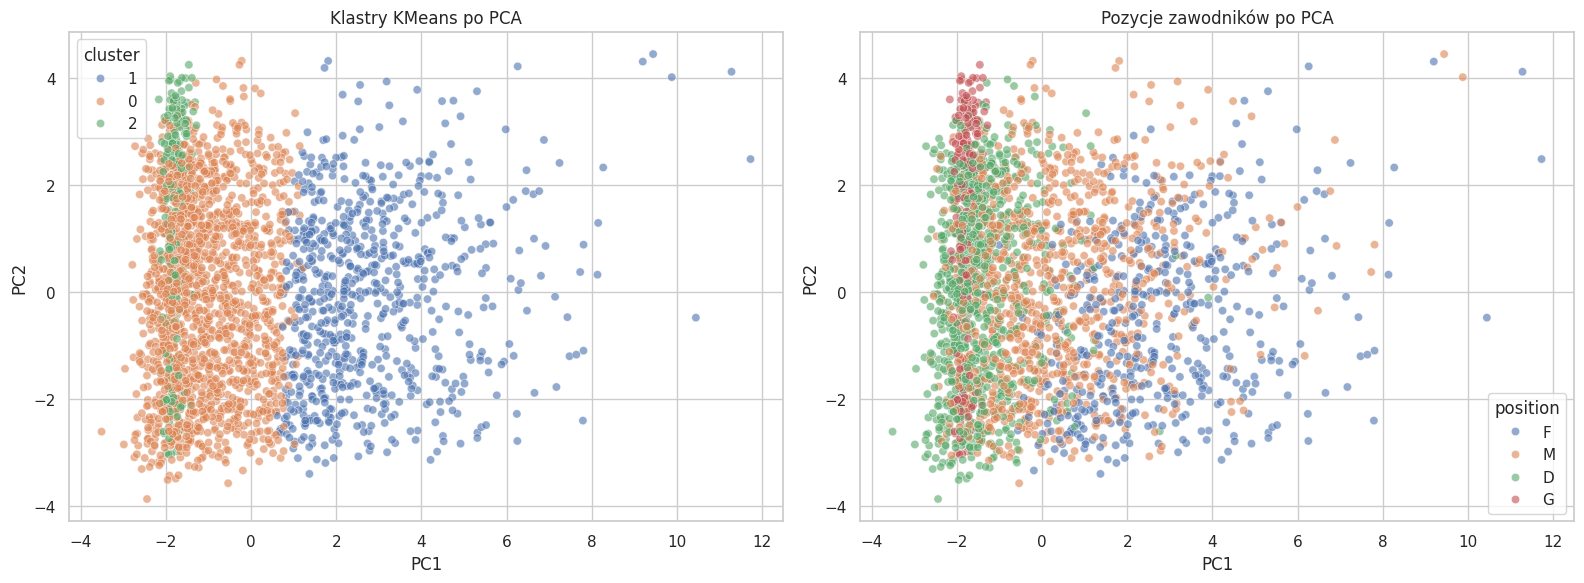

Explained variance ratio: [0.28088938 0.19034438]
Total explained variance: 0.4712


In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": clusters.astype(str),
    "position": df["position"].values,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", alpha=0.6, ax=axes[0])
axes[0].set_title("Klastry KMeans po PCA")

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="position", alpha=0.6, ax=axes[1])
axes[1].set_title("Pozycje zawodników po PCA")

plt.tight_layout()
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

## 4d. Zawodnicy z klastrów

In [13]:
for c in range(N_CLUSTERS):
    subset = analysis_df[analysis_df["cluster"] == c]
    top = subset.nlargest(5, "rating")[["name", "position", "league", "rating", "goals", "assists", "market_value"]]
    print(f"\n--- Cluster {c} (n={len(subset)}) — top 5 by rating ---")
    print(top.to_string(index=False))


--- Cluster 0 (n=1642) — top 5 by rating ---
              name position        league   rating  goals  assists  market_value
Nico Schlotterbeck        D    Bundesliga 7.686957      4        1    57000000.0
  Manuel Locatelli        M       Serie A 7.686667      1        2    24000000.0
    Gonçalo Inácio        D Liga Portugal 7.560000      1        3    42000000.0
       Luka Modrić        M       Serie A 7.535484      2        3     4400000.0
  Nicolas Otamendi        D Liga Portugal 7.503846      2        0     1100000.0

--- Cluster 1 (n=742) — top 5 by rating ---
         name position     league   rating  goals  assists  market_value
 Joey Veerman        M Eredivisie 8.000000      8       14    28000000.0
 Lamine Yamal        M     LaLiga 7.922222     15       11   215000000.0
   Harry Kane        F Bundesliga 7.919231     31        5    71000000.0
   Mika Godts        F Eredivisie 7.803571     15       10    23000000.0
Michael Olise        M Bundesliga 7.785185     12       18

## 4e. chechy dla PC1 i PC2

In [14]:
feature_names = numeric_features + list(
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"]
)

print("Top cechy dla PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))

print("\nTop cechy dla PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))

Top cechy dla PC1:
shots_on_target_per90     0.436213
total_shots_per90         0.428729
expected_goals_per90      0.417600
goals_per90               0.404853
expected_assists_per90    0.268960
Name: PC1, dtype: float64

Top cechy dla PC2:
minutes_played     0.545479
matches_started    0.540035
appearances        0.463674
rating             0.292531
yellow_cards       0.244318
Name: PC2, dtype: float64


In [15]:
players = ["Szczęsny", "Lewandowski"]

result = analysis_df[analysis_df["name"].str.contains("|".join(players), case=False, na=False)][
    ["name", "position", "league", "cluster", "goals"]
]
print(result)

                   name position  league  cluster  goals
355  Robert Lewandowski        F  LaLiga        1     12


---
## 5. Regresja — przewidywanie wartości rynkowej

In [16]:
DATA_DIR = Path("data/13")

profiles_df = pd.read_csv(DATA_DIR / "all_player_profiles.csv")
stats_df = pd.read_csv(DATA_DIR / "all_player_stats.csv")

df = profiles_df.merge(stats_df, on=["player_id", "league"], how="inner")

df = df[df["minutes_played"] >= 600].reset_index(drop=True)

per90_cols = [
    "goals", "assists", "tackles", "interceptions", "saves",
    "total_shots", "shots_on_target", "expected_goals", "expected_assists",
]
for col in per90_cols:
    df[f"{col}_per90"] = df[col] * 90 / df["minutes_played"]

print(f"Zawodnicy po filtrze: {len(df)}")
print(f"Pozycje: {df['position'].value_counts().to_dict()}")
df.head()

Zawodnicy po filtrze: 2580
Pozycje: {'M': 1015, 'D': 900, 'F': 469, 'G': 196}


,player_id,name,league,position,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves,goals_per90,assists_per90,tackles_per90,interceptions_per90,saves_per90,total_shots_per90,shots_on_target_per90,expected_goals_per90,expected_assists_per90
0,804508,Viktor Gyökeres,Premier League,F,61000000.0,30,24,1997,12,0,10.3733,1.773005,6.573333,47,18,5,0,6,1,0,0.540811,0.000000,0.270406,0.045068,0.0,2.118177,0.811217,0.467500,0.079905
1,934235,Bukayo Saka,Premier League,F,126000000.0,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0,0.269865,0.134933,1.619190,0.629685,0.0,2.833583,1.169415,0.314577,0.259158
2,922573,Gabriel Martinelli,Premier League,F,42000000.0,26,10,906,1,3,3.3793,0.999809,6.607692,25,10,2,0,10,0,0,0.099338,0.298013,0.993377,0.000000,0.0,2.483444,0.993377,0.335692,0.099319
3,135666,Leandro Trossard,Premier League,F,21000000.0,27,18,1721,5,5,4.8222,2.685569,6.859259,44,11,1,0,25,8,0,0.261476,0.261476,1.307379,0.418361,0.0,2.300988,0.575247,0.252178,0.140442
4,547410,Martin Ødegaard,Premier League,M,71000000.0,20,13,1078,1,5,1.0108,2.924704,6.995000,20,7,0,0,17,7,0,0.083488,0.417440,1.419295,0.584416,0.0,1.669759,0.584416,0.084390,0.244178


## 5a. Regresja liniowa

Próbki: 2573


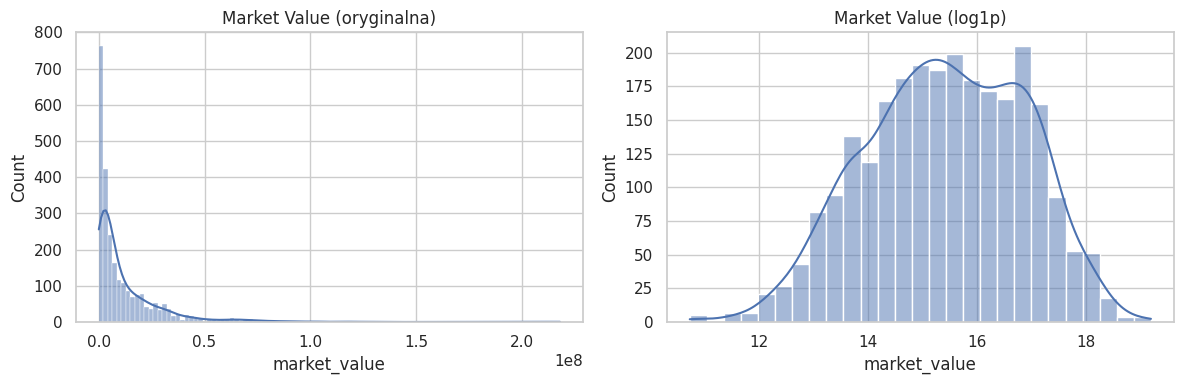

In [18]:
reg_features = [
    "goals_per90", "assists_per90", "expected_goals_per90", "expected_assists_per90",
    "rating", "appearances", "minutes_played",
    "total_shots_per90", "shots_on_target_per90",
    "tackles_per90", "interceptions_per90", "saves_per90",
    "yellow_cards",
]

reg_df = df[reg_features + ["position", "market_value"]].dropna(subset=["market_value"])

X_reg = reg_df[reg_features + ["position"]]
y_reg = np.log1p(reg_df["market_value"])  

print(f"Próbki: {len(X_reg)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(reg_df["market_value"], kde=True, ax=axes[0])
axes[0].set_title("Market Value (oryginalna)")
sns.histplot(y_reg, kde=True, ax=axes[1])
axes[1].set_title("Market Value (log1p)")
plt.tight_layout()
plt.show()

In [19]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

numeric_features = reg_features
categorical_features = ["position"]

reg_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
])

reg_pipeline = Pipeline([
    ("preprocess", reg_preprocessor),
    ("model", LinearRegression()),
])

reg_pipeline.fit(X_train_reg, y_train_reg)

train_pred_reg = reg_pipeline.predict(X_train_reg)
test_pred_reg = reg_pipeline.predict(X_test_reg)

reg_metrics = pd.DataFrame({
    "split": ["train", "test"],
    "MAE": [
        mean_absolute_error(y_train_reg, train_pred_reg),
        mean_absolute_error(y_test_reg, test_pred_reg),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_reg, train_pred_reg)),
        np.sqrt(mean_squared_error(y_test_reg, test_pred_reg)),
    ],
    "R2": [
        r2_score(y_train_reg, train_pred_reg),
        r2_score(y_test_reg, test_pred_reg),
    ],
})
print("Metryki w przestrzeni log1p:")
reg_metrics

Metryki w przestrzeni log1p:


,split,MAE,RMSE,R2
0,train,1.070158,1.301438,0.220440
1,test,1.032347,1.268690,0.142902


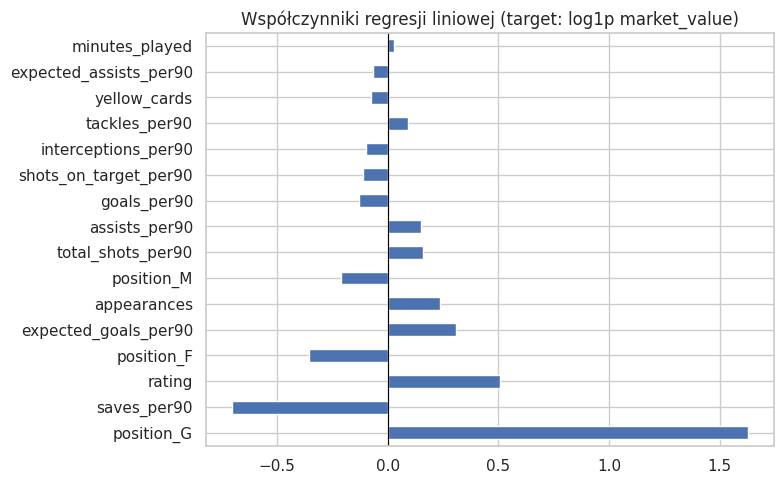

position_G                1.629246
saves_per90              -0.704280
rating                    0.506321
position_F               -0.356636
expected_goals_per90      0.309439
appearances               0.236398
position_M               -0.210163
total_shots_per90         0.156609
assists_per90             0.150524
goals_per90              -0.130935
shots_on_target_per90    -0.112399
interceptions_per90      -0.098583
tackles_per90             0.091790
yellow_cards             -0.077153
expected_assists_per90   -0.066342
minutes_played            0.028317
dtype: float64

In [20]:
cat_names = list(
    reg_pipeline.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(["position"])
)
all_feature_names = numeric_features + cat_names

coef_reg = pd.Series(
    reg_pipeline.named_steps["model"].coef_,
    index=all_feature_names,
).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
coef_reg.plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Współczynniki regresji liniowej (target: log1p market_value)")
plt.tight_layout()
plt.show()

coef_reg

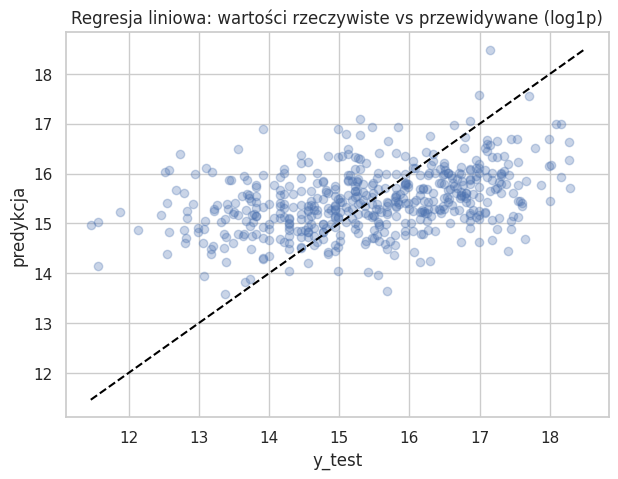

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_reg, test_pred_reg, alpha=0.3)
lims = [min(y_test_reg.min(), test_pred_reg.min()), max(y_test_reg.max(), test_pred_reg.max())]
ax.plot(lims, lims, color="black", linestyle="--")
ax.set_title("Regresja liniowa: wartości rzeczywiste vs przewidywane (log1p)")
ax.set_xlabel("y_test")
ax.set_ylabel("predykcja")
plt.show()

## 5b. Regularyzacja — LinearRegression vs Ridge vs Lasso

In [22]:
def make_reg_pipe(model):
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ])
    return Pipeline([("preprocess", preprocessor), ("model", model)])


models_reg = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0),
    "Ridge(alpha=10.0)": Ridge(alpha=10.0),
    "Lasso(alpha=0.01)": Lasso(alpha=0.01),
    "Lasso(alpha=0.1)": Lasso(alpha=0.1),
}

reg_comparison = []
for name, model in models_reg.items():
    pipe = make_reg_pipe(model)
    pipe.fit(X_train_reg, y_train_reg)
    reg_comparison.append({
        "model": name,
        "r2_train": r2_score(y_train_reg, pipe.predict(X_train_reg)),
        "r2_test": r2_score(y_test_reg, pipe.predict(X_test_reg)),
        "mae_test": mean_absolute_error(y_test_reg, pipe.predict(X_test_reg)),
    })

pd.DataFrame(reg_comparison).sort_values("r2_test", ascending=False).reset_index(drop=True)

,model,r2_train,r2_test,mae_test
0,LinearRegression,0.220440,0.142902,1.032347
1,Ridge(alpha=1.0),0.220359,0.141697,1.033109
2,Lasso(alpha=0.01),0.210735,0.137242,1.042245
3,Ridge(alpha=10.0),0.218742,0.136897,1.036500
4,Lasso(alpha=0.1),0.186296,0.135935,1.053712


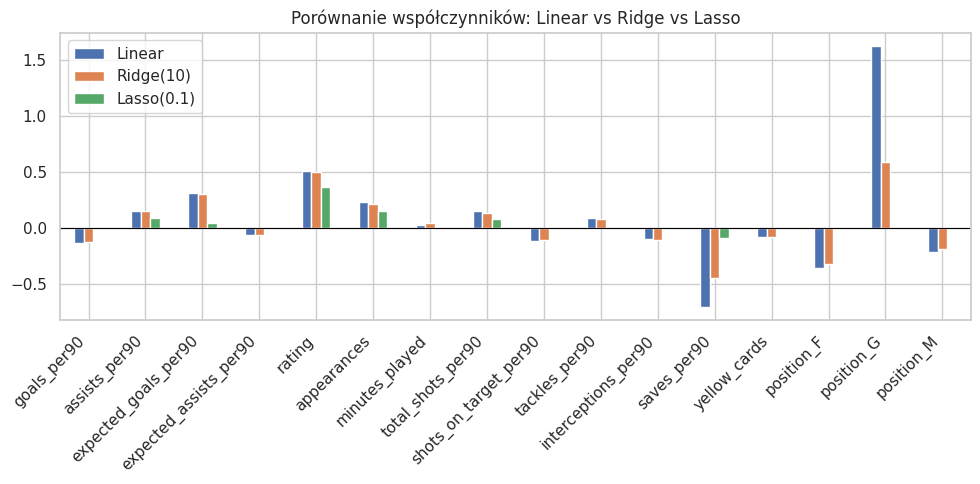

,Linear,Ridge(10),Lasso(0.1)
goals_per90,-0.130935,-0.127368,0.000000
assists_per90,0.150524,0.149511,0.088149
expected_goals_per90,0.309439,0.305664,0.041766
expected_assists_per90,-0.066342,-0.062893,0.000000
rating,0.506321,0.496956,0.363921
appearances,0.236398,0.216102,0.154959
minutes_played,0.028317,0.048269,0.000000
total_shots_per90,0.156609,0.134804,0.079319
shots_on_target_per90,-0.112399,-0.104181,0.000000
tackles_per90,0.091790,0.084475,0.000000


In [23]:
coef_comparison = pd.DataFrame(index=all_feature_names)

for name, model in [
    ("Linear", LinearRegression()),
    ("Ridge(10)", Ridge(alpha=10.0)),
    ("Lasso(0.1)", Lasso(alpha=0.1)),
]:
    pipe = make_reg_pipe(model)
    pipe.fit(X_train_reg, y_train_reg)
    coef_comparison[name] = pipe.named_steps["model"].coef_

fig, ax = plt.subplots(figsize=(10, 5))
coef_comparison.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Porównanie współczynników: Linear vs Ridge vs Lasso")
ax.set_xticklabels(all_feature_names, rotation=45, ha="right")
plt.tight_layout()
plt.show()

coef_comparison

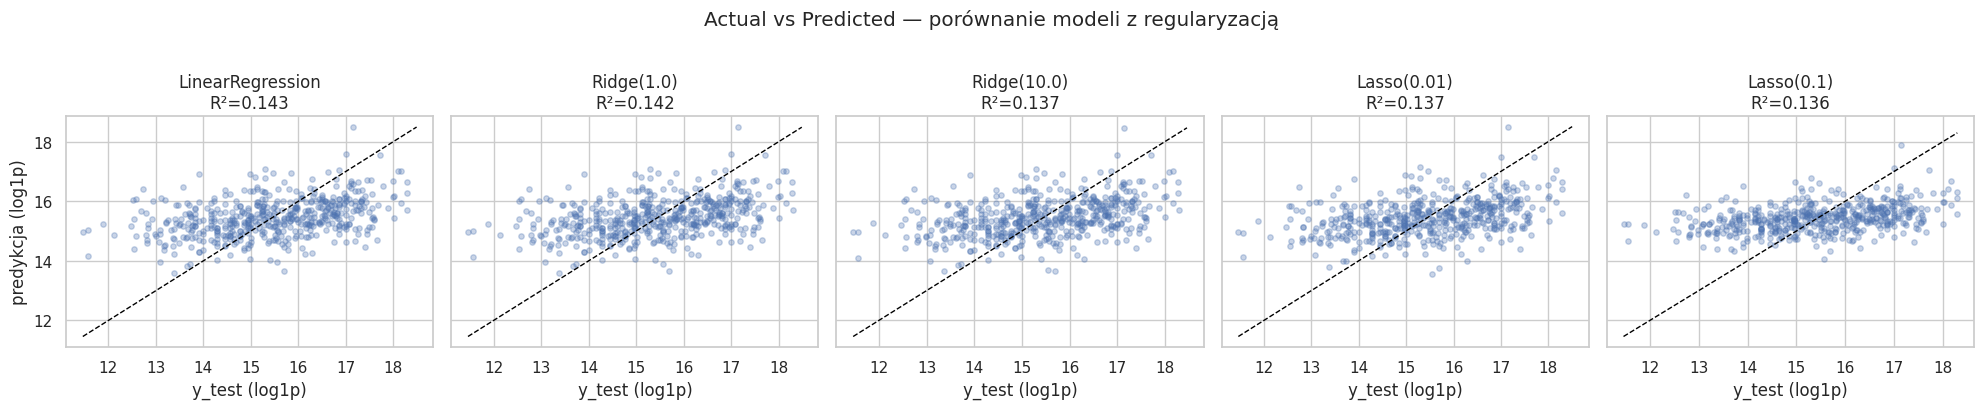

In [24]:
models_to_compare = [
    ("LinearRegression", LinearRegression()),
    ("Ridge(1.0)",       Ridge(alpha=1.0)),
    ("Ridge(10.0)",      Ridge(alpha=10.0)),
    ("Lasso(0.01)",      Lasso(alpha=0.01)),
    ("Lasso(0.1)",       Lasso(alpha=0.1)),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, (name, model) in zip(axes, models_to_compare):
    pipe = make_reg_pipe(model)
    pipe.fit(X_train_reg, y_train_reg)
    preds = pipe.predict(X_test_reg)
    r2 = r2_score(y_test_reg, preds)

    ax.scatter(y_test_reg, preds, alpha=0.3, s=15)
    lims = [
        min(float(y_test_reg.min()), float(preds.min())),
        max(float(y_test_reg.max()), float(preds.max())),
    ]
    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{name}\nR²={r2:.3f}")
    ax.set_xlabel("y_test (log1p)")

axes[0].set_ylabel("predykcja (log1p)")
plt.suptitle("Actual vs Predicted — porównanie modeli z regularyzacją", y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Klasyfikacja - pozycja zawodnika

In [25]:
DATA_DIR = Path("data/13")

profiles_df = pd.read_csv(DATA_DIR / "all_player_profiles.csv")
stats_df = pd.read_csv(DATA_DIR / "all_player_stats.csv")

df = profiles_df.merge(stats_df, on=["player_id", "league"], how="inner", validate="one_to_one")
print(f"Profiles: {len(profiles_df)}, Stats: {len(stats_df)}, Merged: {len(df)}")
df.head()

Profiles: 4740, Stats: 3749, Merged: 3749


,player_id,name,league,position,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
0,804508,Viktor Gyökeres,Premier League,F,61000000.0,30,24,1997,12,0,10.3733,1.773005,6.573333,47,18,5,0,6,1,0
1,934235,Bukayo Saka,Premier League,F,126000000.0,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0
2,794839,Gabriel Jesus,Premier League,F,21000000.0,12,2,320,2,0,1.8434,0.247789,6.541667,15,10,2,0,4,2,0
3,922573,Gabriel Martinelli,Premier League,F,42000000.0,26,10,906,1,3,3.3793,0.999809,6.607692,25,10,2,0,10,0,0
4,836705,Kai Havertz,Premier League,F,48000000.0,7,4,318,0,1,1.2721,0.105223,6.557143,7,1,0,0,5,0,0


In [26]:
feature_columns = ['market_value', 'appearances', 'matches_started', 'minutes_played', 
                'goals', 'assists', 'expected_goals', 'expected_assists', 'rating',
                'total_shots', 'shots_on_target', 'yellow_cards', 'red_cards', 'tackles',
                'interceptions', 'saves']
X = df[feature_columns]

position_map = {'F': 0, 'M': 1, 'D': 2, 'G': 3}
y = df['position'].map(position_map)

### 6a. Preprocessing + training

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
], memory=None)

model = Pipeline([
    ("preprocess", preprocessor),
    ("model", OneVsRestClassifier(LogisticRegression(random_state=42)))
], memory=None)

model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Ca

### 6b. Predykcja

In [28]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_proba = model.predict_proba(X_train)
test_proba = model.predict_proba(X_test)

metrics = pd.DataFrame({
    "split": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, train_pred),
        accuracy_score(y_test, test_pred)
    ],
    "roc_auc": [
        roc_auc_score(y_train, train_proba, multi_class='ovr'),
        roc_auc_score(y_test, test_proba, multi_class='ovr')
    ]
})

metrics

,split,accuracy,roc_auc
0,train,0.698233,0.903657
1,test,0.678667,0.899755


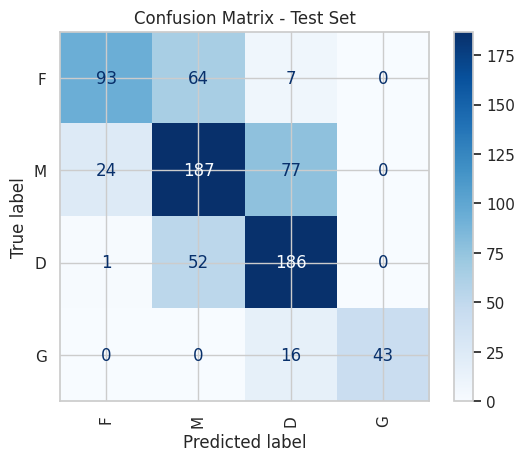

In [29]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['F', 'M', 'D', 'G'])
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.show()

### 6c. Porównanie modeli

In [30]:
models = [LogisticRegression, SVC, KNeighborsClassifier,
           DecisionTreeClassifier, RandomForestClassifier]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
], memory=None)

results = []

for model in models:
    if model == KNeighborsClassifier:
        classifier = Pipeline([
            ("preprocess", preprocessor),
            ("model", OneVsRestClassifier(model()))
        ], memory=None)
    elif model == SVC:
        classifier = Pipeline([
            ("preprocess", preprocessor),
            ("model", OneVsRestClassifier(model(probability=True, random_state=42)))
        ], memory=None)
    else:
        classifier = Pipeline([
            ("preprocess", preprocessor),
            ("model", OneVsRestClassifier(model(random_state=42)))
        ], memory=None)

    classifier.fit(X_train, y_train)

    # Make predictions
    train_pred = classifier.predict(X_train)
    test_pred = classifier.predict(X_test)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    test_precision = precision_score(y_test, test_pred, average='macro')
    test_recall = recall_score(y_test, test_pred, average='macro')


    results.append({
        'model': model.__name__,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'precision': test_precision,
        'recall': test_recall
    })

# Display results
results_df = pd.DataFrame(results)
results_df

,model,train_accuracy,test_accuracy,precision,recall
0,LogisticRegression,0.698233,0.678667,0.763912,0.680859
1,SVC,0.728243,0.724000,0.771544,0.774750
2,KNeighborsClassifier,0.777259,0.652000,0.720074,0.702694
3,DecisionTreeClassifier,1.000000,0.562667,0.664784,0.660874
4,RandomForestClassifier,1.000000,0.705333,0.774208,0.750529


---
## 7. Weryfikacja hipotez statystycznych

**Pytania badawcze:**

1. Czy napastnicy (F) strzelają istotnie więcej bramek na 90 minut niż pomocnicy (M)?
2. Czy zawodnicy z Premier League mają istotnie wyższy rating niż zawodnicy z pozostałych lig?

In [ ]:
DATA_DIR = Path("data/13")

profiles_df = pd.read_csv(DATA_DIR / "all_player_profiles.csv")
stats_df    = pd.read_csv(DATA_DIR / "all_player_stats.csv")

df = profiles_df.merge(stats_df, on=["player_id", "league"], how="inner")

# minimum 600 minut — jak w poprzednich notebookach
df = df[df["minutes_played"] >= 600].reset_index(drop=True)

df["goals_per90"] = df["goals"] * 90 / df["minutes_played"]

print(f"Zawodnicy po filtrze: {len(df)}")
print(f"Pozycje: {df['position'].value_counts().to_dict()}")
print(f"Ligi: {df['league'].value_counts().to_dict()}")

---
### 7.1 Pytanie 1 — goals_per90: Napastnicy (F) vs Pomocnicy (M)

**Hipotezy:**
- H₀: Rozkład `goals_per90` jest identyczny dla napastników i pomocników (mediany są równe).
- H₁: Napastnicy mają wyższe `goals_per90` niż pomocnicy (test jednostronny).

In [ ]:
forwards    = df[df["position"] == "F"]["goals_per90"].to_numpy()
midfielders = df[df["position"] == "M"]["goals_per90"].to_numpy()

summary = pd.DataFrame({
    "group":  ["Forwards (F)", "Midfielders (M)"],
    "n":      [len(forwards), len(midfielders)],
    "mean":   [forwards.mean(), midfielders.mean()],
    "median": [np.median(forwards), np.median(midfielders)],
    "std":    [forwards.std(ddof=1), midfielders.std(ddof=1)],
}).round(4)
summary

In [ ]:
subset_fm = df[df["position"].isin(["F", "M"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=subset_fm, x="goals_per90", hue="position",
    bins=30, kde=True, ax=axes[0], element="step"
)
axes[0].set_title("Rozkład goals/90 — F vs M")

sns.boxplot(
    data=subset_fm, x="position", y="goals_per90", ax=axes[1],
    order=["F", "M"]
)
sns.stripplot(
    data=subset_fm, x="position", y="goals_per90", ax=axes[1],
    order=["F", "M"], color="black", alpha=0.15, size=2
)
axes[1].set_title("goals/90 — boxplot")

plt.tight_layout()
plt.show()

### 7.2 Sprawdzenie założenia normalności — Shapiro-Wilk

Test Shapiro-Wilka sprawdza, czy próbka pochodzi z rozkładu normalnego.  
Jeśli `p < 0.05` → odrzucamy normalność i przechodzimy do testu nieparametrycznego.

In [ ]:
shapiro_f = stats.shapiro(forwards)
shapiro_m = stats.shapiro(midfielders)

shapiro_results = pd.DataFrame({
    "group":     ["Forwards (F)", "Midfielders (M)"],
    "statistic": [shapiro_f.statistic, shapiro_m.statistic],
    "p_value":   [shapiro_f.pvalue, shapiro_m.pvalue],
    "normal?": [
        "TAK" if shapiro_f.pvalue > 0.05 else "NIE",
        "TAK" if shapiro_m.pvalue > 0.05 else "NIE",
    ],
})
shapiro_results

### 7.3 Test U Manna-Whitneya


In [ ]:
mw = stats.mannwhitneyu(forwards, midfielders, alternative="greater")

# effect size r = Z / sqrt(N)
n_total = len(forwards) + len(midfielders)
expected_U = len(forwards) * len(midfielders) / 2
std_U = np.sqrt(len(forwards) * len(midfielders) * (n_total + 1) / 12)
z_score = (mw.statistic - expected_U) / std_U
effect_r = abs(z_score) / np.sqrt(n_total)

mw_results = pd.DataFrame({
    "test":        ["Mann-Whitney U (F > M)"],
    "U statistic": [mw.statistic],
    "p_value":     [mw.pvalue],
    "z_score":     [z_score],
    "effect r":    [effect_r],
})
mw_results

### 7.4 Bootstrap — przedział ufności dla różnicy median

In [ ]:
N_BOOT = 5000
boot_diffs = np.empty(N_BOOT)

for i in range(N_BOOT):
    fb = np.random.choice(forwards,    size=len(forwards),    replace=True)
    mb = np.random.choice(midfielders, size=len(midfielders), replace=True)
    boot_diffs[i] = np.median(fb) - np.median(mb)

ci_low, ci_high = np.quantile(boot_diffs, [0.025, 0.975])
observed_diff   = np.median(forwards) - np.median(midfielders)

print(f"Obserwowana różnica median:  {observed_diff:.4f} bramki/90 min")
print(f"Bootstrap 95% CI:            [{ci_low:.4f}, {ci_high:.4f}]")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(boot_diffs, bins=50, kde=True, ax=ax)
ax.axvline(ci_low,         color="red",    linestyle="--", label=f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
ax.axvline(ci_high,        color="red",    linestyle="--")
ax.axvline(observed_diff,  color="green",  linestyle="-",  label=f"Obserwowana różnica: {observed_diff:.4f}")
ax.axvline(0,              color="black",  linestyle=":",  label="zero")
ax.set_title("Bootstrap — rozkład różnicy median goals/90 (F − M)")
ax.set_xlabel("Różnica median")
ax.legend()
plt.tight_layout()
plt.show()

---
### 7.6 Pytanie 2 — Rating: Premier League vs pozostałe ligi

**Hipotezy:**
- H₀: Średni rating zawodników Premier League jest równy średniemu ratingowi z pozostałych lig.
- H₁: Średni rating zawodników Premier League jest różny (test dwustronny).

In [ ]:
pl_rating    = df[df["league"] == "Premier League"]["rating"].to_numpy()
other_rating = df[df["league"] != "Premier League"]["rating"].to_numpy()

summary2 = pd.DataFrame({
    "group":  ["Premier League", "Pozostałe ligi"],
    "n":      [len(pl_rating), len(other_rating)],
    "mean":   [pl_rating.mean(), other_rating.mean()],
    "median": [np.median(pl_rating), np.median(other_rating)],
    "std":    [pl_rating.std(ddof=1), other_rating.std(ddof=1)],
}).round(4)
summary2

In [ ]:
df["group"] = df["league"].apply(lambda x: "Premier League" if x == "Premier League" else "Pozostałe ligi")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df, x="rating", hue="group",
    bins=40, kde=True, ax=axes[0], element="step"
)
axes[0].set_title("Rozkład ratingu — PL vs pozostałe")

sns.boxplot(
    data=df, x="group", y="rating", ax=axes[1],
    order=["Premier League", "Pozostałe ligi"]
)
sns.stripplot(
    data=df, x="group", y="rating", ax=axes[1],
    order=["Premier League", "Pozostałe ligi"],
    color="black", alpha=0.08, size=2
)
axes[1].set_title("Rating — boxplot")

plt.tight_layout()
plt.show()

### 7.7 Shapiro-Wilk + Levene

In [ ]:
shapiro_pl    = stats.shapiro(pl_rating)
shapiro_other = stats.shapiro(other_rating)
levene_test   = stats.levene(pl_rating, other_rating)

shapiro2 = pd.DataFrame({
    "group":     ["Premier League", "Pozostałe ligi"],
    "statistic": [shapiro_pl.statistic, shapiro_other.statistic],
    "p_value":   [shapiro_pl.pvalue, shapiro_other.pvalue],
    "normal?": [
        "TAK" if shapiro_pl.pvalue > 0.05 else "NIE",
        "TAK" if shapiro_other.pvalue > 0.05 else "NIE",
    ],
})
print(shapiro2.to_string(index=False))
print(f"\nLevene: statistic={levene_test.statistic:.4f}, p={levene_test.pvalue:.4f}")
print(f"Równe wariancje? {'TAK' if levene_test.pvalue > 0.05 else 'NIE'}")

### 7.8 Wybór testu na podstawie wyników powyżej

In [ ]:
welch = stats.ttest_ind(pl_rating, other_rating, equal_var=False)
mw2   = stats.mannwhitneyu(pl_rating, other_rating, alternative="two-sided")

comparison = pd.DataFrame({
    "test":        ["Welch t-test", "Mann-Whitney U"],
    "statistic":   [welch.statistic, mw2.statistic],
    "p_value":     [welch.pvalue, mw2.pvalue],
    "istotny?": [
        "TAK" if welch.pvalue < 0.05 else "NIE",
        "TAK" if mw2.pvalue < 0.05 else "NIE",
    ],
})
comparison

### 7.9 Przedział ufności dla różnicy średnich (Welch)

In [ ]:
mean_diff = pl_rating.mean() - other_rating.mean()
se = np.sqrt(
    pl_rating.var(ddof=1) / len(pl_rating) +
    other_rating.var(ddof=1) / len(other_rating)
)

# stopnie swobody Welcha
df_welch = (
    (pl_rating.var(ddof=1) / len(pl_rating) + other_rating.var(ddof=1) / len(other_rating)) ** 2
    / (
        (pl_rating.var(ddof=1) / len(pl_rating)) ** 2 / (len(pl_rating) - 1)
        + (other_rating.var(ddof=1) / len(other_rating)) ** 2 / (len(other_rating) - 1)
    )
)

ci_low2, ci_high2 = stats.t.interval(0.95, df=df_welch, loc=mean_diff, scale=se)

print(f"Różnica średnich (PL − inne): {mean_diff:+.4f}")
print(f"95% CI:                        [{ci_low2:.4f}, {ci_high2:.4f}]")
print(f"CI zawiera zero?               {'TAK' if ci_low2 < 0 < ci_high2 else 'NIE'}")